In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv('/content/MUP_DP__Geo.csv', low_memory=False)


print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())

Shape: (117661, 22)

Columns: ['Prscrbr_Geo_Lvl', 'Prscrbr_Geo_Cd', 'Prscrbr_Geo_Desc', 'Brnd_Name', 'Gnrc_Name', 'Tot_Prscrbrs', 'Tot_Clms', 'Tot_30day_Fills', 'Tot_Drug_Cst', 'Tot_Benes', 'GE65_Sprsn_Flag', 'GE65_Tot_Clms', 'GE65_Tot_30day_Fills', 'GE65_Tot_Drug_Cst', 'GE65_Bene_Sprsn_Flag', 'GE65_Tot_Benes', 'LIS_Bene_Cst_Shr', 'NonLIS_Bene_Cst_Shr', 'Opioid_Drug_Flag', 'Opioid_LA_Drug_Flag', 'Antbtc_Drug_Flag', 'Antpsyct_Drug_Flag']


In [3]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head()

Shape: (117661, 22)

Columns: ['Prscrbr_Geo_Lvl', 'Prscrbr_Geo_Cd', 'Prscrbr_Geo_Desc', 'Brnd_Name', 'Gnrc_Name', 'Tot_Prscrbrs', 'Tot_Clms', 'Tot_30day_Fills', 'Tot_Drug_Cst', 'Tot_Benes', 'GE65_Sprsn_Flag', 'GE65_Tot_Clms', 'GE65_Tot_30day_Fills', 'GE65_Tot_Drug_Cst', 'GE65_Bene_Sprsn_Flag', 'GE65_Tot_Benes', 'LIS_Bene_Cst_Shr', 'NonLIS_Bene_Cst_Shr', 'Opioid_Drug_Flag', 'Opioid_LA_Drug_Flag', 'Antbtc_Drug_Flag', 'Antpsyct_Drug_Flag']


,Prscrbr_Geo_Lvl,Prscrbr_Geo_Cd,Prscrbr_Geo_Desc,Brnd_Name,Gnrc_Name,Tot_Prscrbrs,Tot_Clms,Tot_30day_Fills,Tot_Drug_Cst,Tot_Benes,...,GE65_Tot_30day_Fills,GE65_Tot_Drug_Cst,GE65_Bene_Sprsn_Flag,GE65_Tot_Benes,LIS_Bene_Cst_Shr,NonLIS_Bene_Cst_Shr,Opioid_Drug_Flag,Opioid_LA_Drug_Flag,Antbtc_Drug_Flag,Antpsyct_Drug_Flag
0,National,NaN,National,1st Tier Unifine Pentips,"Pen Needle, Diabetic",209,378,695.6,10454.60,213.0,...,584.4,8336.36,NaN,174.0,140.44,3053.27,N,N,N,N
1,National,NaN,National,1st Tier Unifine Pentips Plus,"Pen Needle, Diabetic",442,965,1588.4,26074.56,451.0,...,1301.4,20918.75,NaN,360.0,686.07,5152.25,N,N,N,N
2,National,NaN,National,Abacavir,Abacavir Sulfate,2277,16298,21345.5,3054440.46,2349.0,...,14073.4,1994516.36,NaN,1491.0,6378.08,106462.22,N,N,N,N
3,National,NaN,National,Abacavir-Lamivudine,Abacavir Sulfate/Lamivudine,2162,17348,24469.2,5785643.94,2467.0,...,16985.9,3873672.58,NaN,1708.0,8498.40,266361.31,N,N,N,N
4,National,NaN,National,Abilify,Aripiprazole,1715,7131,9532.7,7066614.48,1478.0,...,3108.4,2038720.65,NaN,536.0,10911.96,119541.25,N,N,N,Y


In [4]:
print(" NULL VALUES ")
print(df.isnull().sum())
print("\n BASIC STATS ")
print(df.describe())

 NULL VALUES 
Prscrbr_Geo_Lvl             0
Prscrbr_Geo_Cd           3633
Prscrbr_Geo_Desc            1
Brnd_Name                   0
Gnrc_Name                   0
Tot_Prscrbrs                0
Tot_Clms                    0
Tot_30day_Fills             0
Tot_Drug_Cst                0
Tot_Benes               21951
GE65_Sprsn_Flag         95939
GE65_Tot_Clms           21722
GE65_Tot_30day_Fills    21722
GE65_Tot_Drug_Cst       21722
GE65_Bene_Sprsn_Flag    67619
GE65_Tot_Benes          50042
LIS_Bene_Cst_Shr            0
NonLIS_Bene_Cst_Shr         0
Opioid_Drug_Flag            0
Opioid_LA_Drug_Flag         0
Antbtc_Drug_Flag            0
Antpsyct_Drug_Flag          0
dtype: int64

 BASIC STATS 
        Tot_Prscrbrs      Tot_Clms  Tot_30day_Fills  Tot_Drug_Cst  \
count  117661.000000  1.176610e+05     1.176610e+05  1.176610e+05   
mean     1674.465014  2.908370e+04     5.339415e+04  4.900425e+06   
std     15359.902680  4.947255e+05     1.079610e+06  1.004429e+08   
min         1.000000  

/tmp/ipykernel_423/3851282775.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_states.index, y=top_states.values, palette='Reds_r')


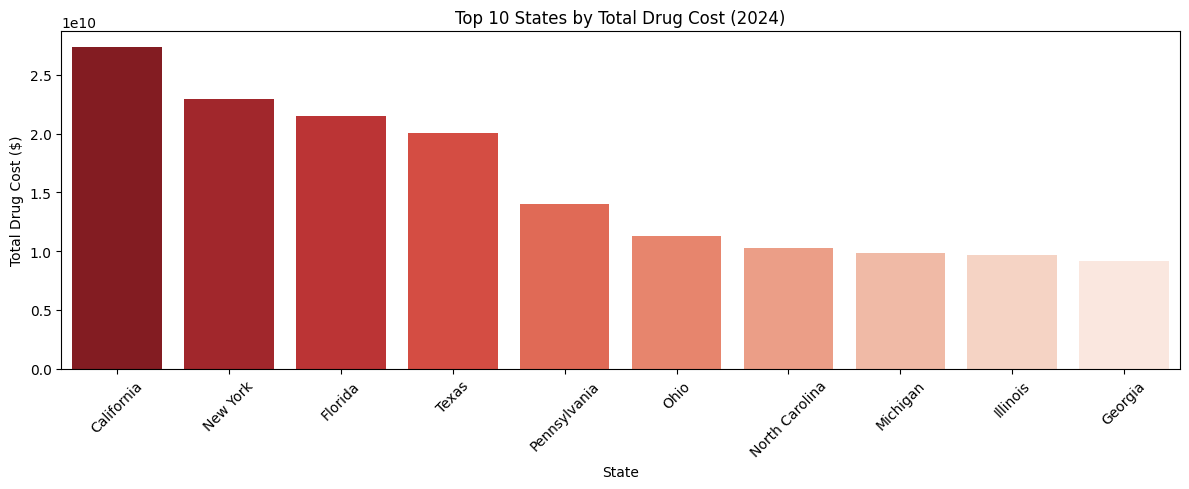

In [5]:

state_df = df[df['Prscrbr_Geo_Lvl'] == 'State']

plt.figure(figsize=(12,5))
top_states = state_df.groupby('Prscrbr_Geo_Desc')['Tot_Drug_Cst'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=top_states.index, y=top_states.values, palette='Reds_r')
plt.title('Top 10 States by Total Drug Cost (2024)')
plt.ylabel('Total Drug Cost ($)')
plt.xlabel('State')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/tmp/ipykernel_423/751793780.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_drugs.values, y=top_drugs.index, palette='Blues_r')


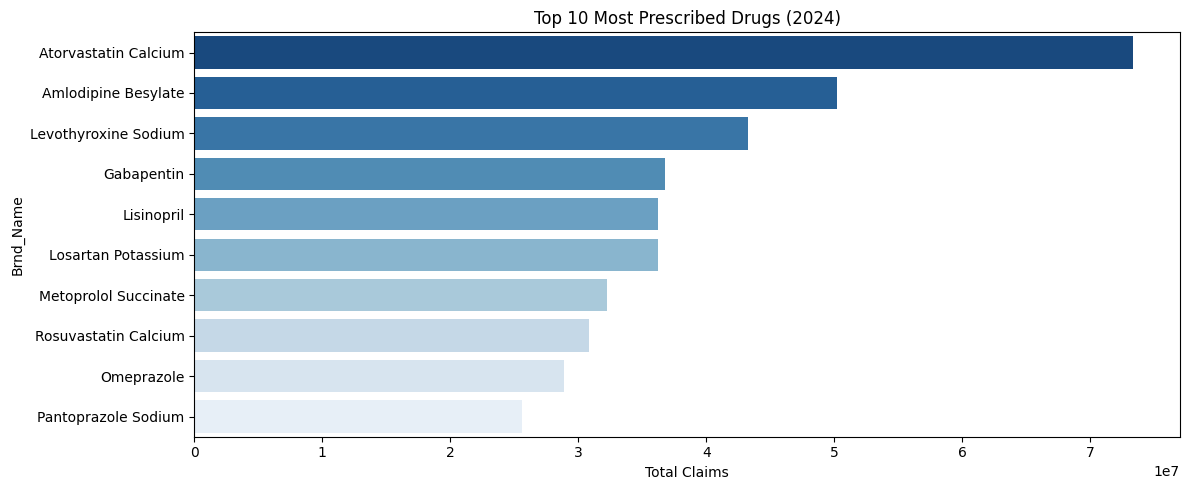

In [6]:
plt.figure(figsize=(12,5))
top_drugs = state_df.groupby('Brnd_Name')['Tot_Clms'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=top_drugs.values, y=top_drugs.index, palette='Blues_r')
plt.title('Top 10 Most Prescribed Drugs (2024)')
plt.xlabel('Total Claims')
plt.tight_layout()
plt.show()

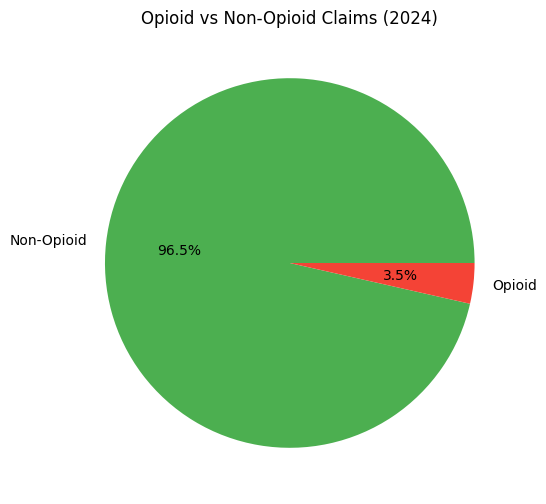

In [7]:
opioid_summary = state_df.groupby('Opioid_Drug_Flag')['Tot_Clms'].sum()
opioid_summary.index = ['Non-Opioid', 'Opioid']
opioid_summary.plot(kind='pie', autopct='%1.1f%%', colors=['#4CAF50','#F44336'],
                    title='Opioid vs Non-Opioid Claims (2024)', figsize=(6,6))
plt.ylabel('')
plt.show()

In [8]:
import sqlite3


conn = sqlite3.connect('medicare_fraud.db')


state_df.to_sql('medicare_claims', conn, if_exists='replace', index=False)

print("✅ Data loaded into SQLite!")
print(f"Total rows: {len(state_df)}")

✅ Data loaded into SQLite!
Total rows: 114029


In [9]:
def run_query(sql):
    return pd.read_sql_query(sql, conn)

In [10]:
run_query("""
    SELECT
        COUNT(DISTINCT Prscrbr_Geo_Desc) AS total_states,
        COUNT(DISTINCT Brnd_Name) AS total_drugs,
        ROUND(SUM(Tot_Clms), 0) AS total_claims,
        ROUND(SUM(Tot_Drug_Cst), 2) AS total_drug_cost
    FROM medicare_claims
""")

,total_states,total_drugs,total_claims,total_drug_cost
0,60,3289,1.710945e+09,2.880192e+11


In [11]:
run_query("""
    SELECT
        Prscrbr_Geo_Desc AS State,
        ROUND(SUM(Tot_Drug_Cst), 2) AS Total_Cost,
        ROUND(SUM(Tot_Clms), 0) AS Total_Claims,
        ROUND(SUM(Tot_Drug_Cst) / SUM(Tot_Clms), 2) AS Cost_Per_Claim
    FROM medicare_claims
    GROUP BY Prscrbr_Geo_Desc
    ORDER BY Cost_Per_Claim DESC
    LIMIT 15
""")

,State,Total_Cost,Total_Claims,Cost_Per_Claim
0,District of Columbia,7.160863e+08,2496852.0,286.80
1,Hawaii,9.973119e+08,4609230.0,216.37
2,New York,2.290424e+10,110762208.0,206.79
3,Alaska,3.962879e+08,1925359.0,205.83
4,Connecticut,4.104129e+09,19983336.0,205.38
5,Massachusetts,7.596536e+09,38255709.0,198.57
6,Maryland,4.529723e+09,23694917.0,191.17
7,New Jersey,8.022282e+09,42023654.0,190.90
8,Colorado,3.697091e+09,20366195.0,181.53
9,Delaware,9.406078e+08,5224158.0,180.05


In [12]:
run_query("""
    SELECT
        Prscrbr_Geo_Desc AS State,
        ROUND(SUM(CASE WHEN Opioid_Drug_Flag = 'Y' THEN Tot_Clms ELSE 0 END), 0) AS Opioid_Claims,
        ROUND(SUM(Tot_Clms), 0) AS Total_Claims,
        ROUND(100.0 * SUM(CASE WHEN Opioid_Drug_Flag = 'Y' THEN Tot_Clms ELSE 0 END) / SUM(Tot_Clms), 2) AS Opioid_Pct
    FROM medicare_claims
    GROUP BY Prscrbr_Geo_Desc
    ORDER BY Opioid_Pct DESC
    LIMIT 15
""")

,State,Opioid_Claims,Total_Claims,Opioid_Pct
0,Armed Forces Central/South America,241.0,3536.0,6.82
1,Armed Forces Pacific,1927.0,36859.0,5.23
2,Alabama,1688226.0,32469635.0,5.20
3,Armed Forces Europe,2039.0,39419.0,5.17
4,Utah,532698.0,10386918.0,5.13
5,Idaho,420681.0,8372069.0,5.02
6,Oklahoma,997685.0,20895171.0,4.77
7,Arkansas,970153.0,20475351.0,4.74
8,Oregon,906735.0,19312503.0,4.70
9,Colorado,950413.0,20366195.0,4.67


In [13]:
run_query("""
    SELECT
        Brnd_Name,
        Gnrc_Name,
        ROUND(SUM(Tot_Drug_Cst), 2) AS Total_Cost,
        ROUND(SUM(Tot_Clms), 0) AS Total_Claims,
        ROUND(SUM(Tot_Drug_Cst) / SUM(Tot_Clms), 2) AS Cost_Per_Claim,
        Opioid_Drug_Flag
    FROM medicare_claims
    GROUP BY Brnd_Name, Gnrc_Name
    HAVING Total_Claims > 1000
    ORDER BY Cost_Per_Claim DESC
    LIMIT 20
""")

,Brnd_Name,Gnrc_Name,Total_Cost,Total_Claims,Cost_Per_Claim,Opioid_Drug_Flag
0,Amvuttra,Vutrisiran Sodium,1.311134e+08,1109.0,118226.70,N
1,Strensiq,Asfotase Alfa,3.430079e+08,3409.0,100618.35,N
2,Mavenclad,Cladribine,1.736804e+08,2350.0,73906.54,N
3,Acthar,Corticotropin,3.568778e+08,4884.0,73070.81,N
4,Cortrophin,Corticotropin,1.266326e+08,2076.0,60998.35,N
5,Ultomiris,Ravulizumab-Cwvz,2.306721e+08,3913.0,58950.19,N
6,Tepezza,Teprotumumab-Trbw,1.484331e+08,2649.0,56033.63,N
7,Vyvgart Hytrulo,Efgartigimod-Hyaluronidas-Qvfc,1.236793e+08,2349.0,52651.91,N
8,Gattex,Teduglutide,3.551115e+08,7043.0,50420.49,N
9,Vyvgart,Efgartigimod Alfa-Fcab,2.375854e+08,4818.0,49312.04,N


In [14]:

fraud_df = state_df.groupby(['Prscrbr_Geo_Desc', 'Brnd_Name', 'Opioid_Drug_Flag']).agg(
    Total_Claims      = ('Tot_Clms', 'sum'),
    Total_Cost        = ('Tot_Drug_Cst', 'sum'),
    Total_Patients    = ('Tot_Benes', 'sum'),
    Total_Prescribers = ('Tot_Prscrbrs', 'sum')
).reset_index()


fraud_df = fraud_df[
    (fraud_df['Total_Claims'] > 0) &
    (fraud_df['Total_Patients'] > 0) &
    (fraud_df['Total_Prescribers'] > 0)
]


fraud_df['Cost_Per_Claim']         = fraud_df['Total_Cost'] / fraud_df['Total_Claims']
fraud_df['Claims_Per_Prescriber']  = fraud_df['Total_Claims'] / fraud_df['Total_Prescribers']
fraud_df['Cost_Per_Patient']       = fraud_df['Total_Cost'] / fraud_df['Total_Patients']
fraud_df['Is_Opioid']              = (fraud_df['Opioid_Drug_Flag'] == 'Y').astype(int)


fraud_df = fraud_df.replace([float('inf'), float('-inf')], float('nan'))
fraud_df = fraud_df.dropna()

print("✅ Features built!")
print(f"Clean rows: {len(fraud_df)}")
fraud_df.head()

✅ Features built!
Clean rows: 89974


,Prscrbr_Geo_Desc,Brnd_Name,Opioid_Drug_Flag,Total_Claims,Total_Cost,Total_Patients,Total_Prescribers,Cost_Per_Claim,Claims_Per_Prescriber,Cost_Per_Patient,Is_Opioid
1,Alabama,Abacavir,N,273,58366.16,41.0,36,213.795458,7.583333,1423.564878,0
2,Alabama,Abacavir-Lamivudine,N,117,30692.35,21.0,18,262.327778,6.500000,1461.540476,0
4,Alabama,Abilify Asimtufii,N,261,1410039.50,72.0,43,5402.450192,6.069767,19583.881944,0
5,Alabama,Abilify Maintena,N,5935,16497769.79,741.0,288,2779.742172,20.607639,22264.196748,0
6,Alabama,Abiraterone Acetate,N,3406,6802896.29,567.0,184,1997.327155,18.510870,11998.053422,0


In [15]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler


features = ['Cost_Per_Claim', 'Claims_Per_Prescriber',
            'Cost_Per_Patient', 'Is_Opioid', 'Total_Claims']

X = fraud_df[features].copy()


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


model = IsolationForest(contamination=0.05, random_state=42, n_estimators=100)
fraud_df['Anomaly'] = model.fit_predict(X_scaled)
fraud_df['Is_Suspicious'] = (fraud_df['Anomaly'] == -1).astype(int)

suspicious_count = fraud_df['Is_Suspicious'].sum()
print(f"✅ Model complete!")
print(f"🚨 Suspicious records flagged: {suspicious_count}")
print(f"📊 Total records: {len(fraud_df)}")

✅ Model complete!
🚨 Suspicious records flagged: 4499
📊 Total records: 89974


In [16]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
fraud_df['Cluster'] = kmeans.fit_predict(X_scaled)


cluster_summary = fraud_df.groupby('Cluster').agg(
    Avg_Cost_Per_Claim       = ('Cost_Per_Claim', 'mean'),
    Avg_Claims_Per_Prescriber = ('Claims_Per_Prescriber', 'mean'),
    Avg_Cost_Per_Patient     = ('Cost_Per_Patient', 'mean'),
    Opioid_Rate              = ('Is_Opioid', 'mean'),
    Count                    = ('Cluster', 'count')
).round(2)

print(" CLUSTER PROFILES ")
print(cluster_summary)

 CLUSTER PROFILES 
         Avg_Cost_Per_Claim  Avg_Claims_Per_Prescriber  Avg_Cost_Per_Patient  \
Cluster                                                                        
0                    264.13                      54.19               2137.87   
1                    361.77                       9.94               2137.84   
2                    763.86                       6.79               3544.87   
3                  19874.77                      10.82             114811.47   

         Opioid_Rate  Count  
Cluster                      
0               0.01   1478  
1               1.00   1561  
2               0.00  81412  
3               0.00   5523  


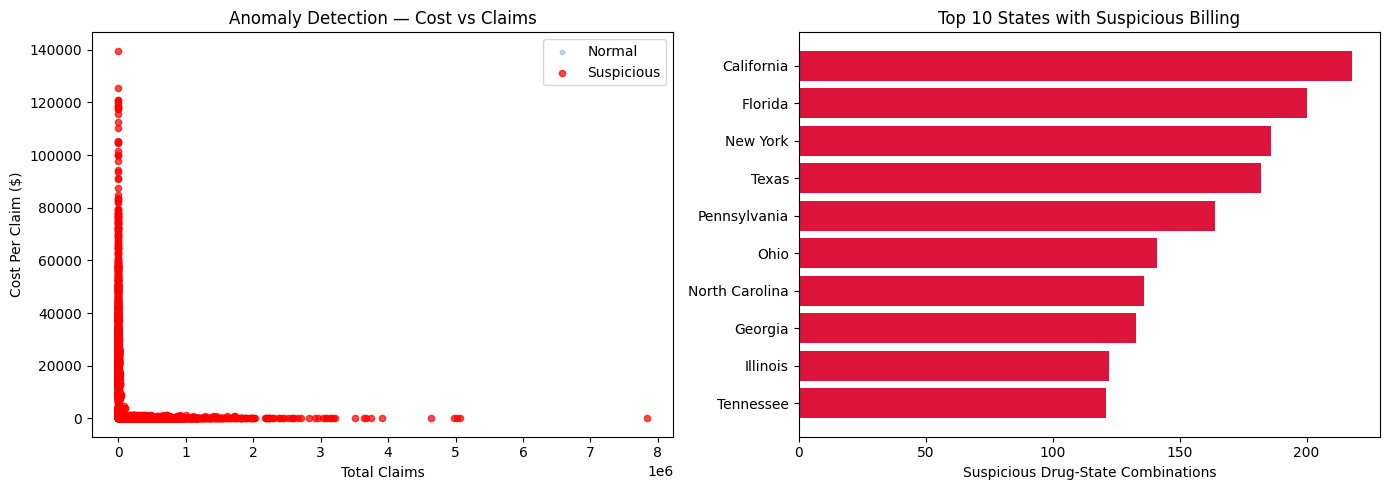

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))


axes[0].scatter(
    fraud_df[fraud_df['Is_Suspicious']==0]['Total_Claims'],
    fraud_df[fraud_df['Is_Suspicious']==0]['Cost_Per_Claim'],
    alpha=0.3, color='steelblue', label='Normal', s=10
)
axes[0].scatter(
    fraud_df[fraud_df['Is_Suspicious']==1]['Total_Claims'],
    fraud_df[fraud_df['Is_Suspicious']==1]['Cost_Per_Claim'],
    alpha=0.7, color='red', label='Suspicious', s=20
)
axes[0].set_xlabel('Total Claims')
axes[0].set_ylabel('Cost Per Claim ($)')
axes[0].set_title('Anomaly Detection — Cost vs Claims')
axes[0].legend()


top_suspicious = fraud_df[fraud_df['Is_Suspicious']==1]\
    .groupby('Prscrbr_Geo_Desc')['Is_Suspicious'].sum()\
    .sort_values(ascending=False).head(10)

axes[1].barh(top_suspicious.index, top_suspicious.values, color='crimson')
axes[1].set_xlabel('Suspicious Drug-State Combinations')
axes[1].set_title('Top 10 States with Suspicious Billing')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

In [18]:
top_suspicious_drugs = fraud_df[fraud_df['Is_Suspicious']==1]\
    .groupby(['Brnd_Name', 'Opioid_Drug_Flag'])\
    .agg(Count=('Is_Suspicious','sum'), Avg_Cost=('Cost_Per_Claim','mean'))\
    .sort_values('Count', ascending=False).head(15)

print(" TOP SUSPICIOUS DRUGS ")
print(top_suspicious_drugs)

 TOP SUSPICIOUS DRUGS 
                                            Count      Avg_Cost
Brnd_Name                 Opioid_Drug_Flag                     
Hydrocodone-Acetaminophen Y                    58     17.905200
Tramadol Hcl              Y                    56      6.968778
Oxycodone-Acetaminophen   Y                    56     25.343578
Oxycodone Hcl             Y                    55     14.263835
Atorvastatin Calcium      N                    54     10.589144
Buprenorphine             Y                    52    248.962887
Oxycontin                 Y                    52    686.832591
Stelara                   N                    51  25564.214733
Xtampza Er                Y                    51    634.662111
Fentanyl                  Y                    51    112.114926
Amlodipine Besylate       N                    51      6.495586
Methadone Hcl             Y                    50     19.918333
Losartan Potassium        N                    50      9.873147
Levothyroxine Sod

In [19]:

suspicious_records = fraud_df[fraud_df['Is_Suspicious']==1][[
    'Prscrbr_Geo_Desc', 'Brnd_Name', 'Opioid_Drug_Flag',
    'Total_Claims', 'Total_Cost', 'Cost_Per_Claim',
    'Claims_Per_Prescriber', 'Cost_Per_Patient', 'Cluster', 'Is_Suspicious'
]]

suspicious_records.to_csv('suspicious_medicare_2024.csv', index=False)
print(f"✅ Saved {len(suspicious_records)} suspicious records!")


fraud_df.to_csv('medicare_fraud_analysis_2024.csv', index=False)
print("✅ Full analysis saved!")

✅ Saved 4499 suspicious records!
✅ Full analysis saved!
